## Read GSOD daily data from DuckDB

This section reads the local GSOD Philippines database using DuckDB. The database has already been converted to metric units, so precipitation is read directly from `PRCP_mm` and is not converted from inches.

The goal is to prepare selected NCR-adjacent GSOD stations in the same daily format used by the Science Garden workflow:

- `STATION_ID`
- `STATION_NAME`
- `LATITUDE`
- `LONGITUDE`
- `DATE`
- `YEAR`
- `MONTH`
- `DAY`
- `RAINFALL`

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import linregress, norm, t

In [6]:
GSOD_EXPORT_DIR = Path("/home/jupyter-bbr/notebooks/gsod/exports")

GSOD_STATION_INVENTORY_PATH = GSOD_EXPORT_DIR / "gsod_station_inventory_1980_2024.csv"
GSOD_DAILY_PATH = GSOD_EXPORT_DIR / "gsod_daily_metric_ncr_adjacent_1980_2024.csv"

OUTPUT_DIR = Path("output")
GSOD_OUTPUT_DIR = OUTPUT_DIR / "gsod_sanity_check"
GSOD_TABLE_DIR = GSOD_OUTPUT_DIR / "tables"
GSOD_FIGURE_DIR = GSOD_OUTPUT_DIR / "figures"

for path in [GSOD_OUTPUT_DIR, GSOD_TABLE_DIR, GSOD_FIGURE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

START_YEAR = 1980
END_YEAR = 2024

WET_DAY_THRESHOLD = 1.0
MIN_VALID_FRACTION = 0.90

DRY_MONTHS = [11, 12, 1, 2, 3, 4]
WET_MONTHS = [5, 6, 7, 8, 9, 10]

DRY_SEASON_LABEL = "Nov-Apr"
WET_SEASON_LABEL = "May-Oct"
SEASON_ORDER = [DRY_SEASON_LABEL, WET_SEASON_LABEL]

In [7]:
station_inventory = pd.read_csv(
    GSOD_STATION_INVENTORY_PATH,
    dtype={"station_id": str}
)

gsod_daily = pd.read_csv(
    GSOD_DAILY_PATH,
    parse_dates=["DATE"],
    dtype={"STATION_ID": str}
)

gsod_daily["RAINFALL"] = pd.to_numeric(gsod_daily["RAINFALL"], errors="coerce")

display(station_inventory.head())
display(gsod_daily.head())

print(gsod_daily.shape)
print(gsod_daily.columns.tolist())

,station_id,station_name,latitude,longitude,first_date,last_date,n_rows,valid_rainfall_days,mean_rainfall_mm,max_rainfall_mm,first_year,last_year,record_years,inside_ncr_adjacent_bbox
0,98430099999,SCIENCE GARDEN,14.650,121.050,1980-01-01,2024-12-31,15402,15117,5.948224,490.982,1980,2024,45,True
1,98429099999,NINOY AQUINO INTL,14.509,121.020,1980-01-01,2024-12-31,16406,14713,2.751411,400.050,1980,2024,45,True
2,98427099999,TAYABAS,14.017,121.600,1980-01-01,2024-12-31,14843,14606,7.523189,500.126,1980,2024,45,True
3,98432099999,AMBULONG,14.083,121.050,1980-01-01,2024-12-31,12818,12650,4.727372,436.372,1980,2024,45,True
4,98425099999,MANILA,14.583,120.983,1981-05-18,2023-11-30,14067,13818,5.339423,427.990,1981,2023,43,True


,STATION_ID,STATION_NAME,LATITUDE,LONGITUDE,DATE,YEAR,MONTH,DAY,RAINFALL
0,69176499999,CLARK INTL,15.183,120.567001,1985-03-12,1985,3,12,0.0
1,69176499999,CLARK INTL,15.183,120.567001,1986-04-18,1986,4,18,NaN
2,69176499999,CLARK INTL,15.183,120.567001,1986-04-19,1986,4,19,NaN
3,69176499999,CLARK INTL,15.183,120.567001,1986-04-22,1986,4,22,NaN
4,69176499999,CLARK INTL,15.183,120.567001,1986-04-23,1986,4,23,NaN


(97347, 9)
['STATION_ID', 'STATION_NAME', 'LATITUDE', 'LONGITUDE', 'DATE', 'YEAR', 'MONTH', 'DAY', 'RAINFALL']


In [8]:
SELECTED_STATION_IDS = [
    "98429099999",
    # "98428099999",
    # "98430099999",
]

In [9]:
SELECTED_STATION_IDS = [str(x).strip() for x in SELECTED_STATION_IDS]

available_ids = set(gsod_daily["STATION_ID"].astype(str).unique())
missing_ids = [x for x in SELECTED_STATION_IDS if x not in available_ids]

if len(missing_ids) > 0:
    print("Missing selected station IDs:")
    print(missing_ids)

gsod_selected = gsod_daily[
    gsod_daily["STATION_ID"].astype(str).isin(SELECTED_STATION_IDS)
].copy()

gsod_selected = gsod_selected.sort_values(["STATION_ID", "DATE"]).reset_index(drop=True)

display(gsod_selected.head())
display(gsod_selected["STATION_ID"].value_counts())

print("Selected stations:", gsod_selected["STATION_ID"].nunique())

,STATION_ID,STATION_NAME,LATITUDE,LONGITUDE,DATE,YEAR,MONTH,DAY,RAINFALL
0,98429099999,NINOY AQUINO INTL,14.509,121.019997,1980-01-01,1980,1,1,0.0
1,98429099999,NINOY AQUINO INTL,14.509,121.019997,1980-01-02,1980,1,2,0.0
2,98429099999,NINOY AQUINO INTL,14.509,121.019997,1980-01-03,1980,1,3,0.0
3,98429099999,NINOY AQUINO INTL,14.509,121.019997,1980-01-04,1980,1,4,0.0
4,98429099999,NINOY AQUINO INTL,14.509,121.019997,1980-01-05,1980,1,5,0.0


STATION_ID
98429099999    16406
Name: count, dtype: int64

Selected stations: 1


In [10]:
def reindex_station_daily(group):
    station_id = group["STATION_ID"].iloc[0]
    
    full_dates = pd.DataFrame({
        "DATE": pd.date_range(
            start=f"{START_YEAR}-01-01",
            end=f"{END_YEAR}-12-31",
            freq="D",
        )
    })
    
    out = full_dates.merge(group, on="DATE", how="left")
    
    out["STATION_ID"] = station_id
    out["YEAR"] = out["DATE"].dt.year
    out["MONTH"] = out["DATE"].dt.month
    out["DAY"] = out["DATE"].dt.day
    
    for col in ["STATION_NAME", "LATITUDE", "LONGITUDE"]:
        if col in out.columns:
            out[col] = out[col].ffill().bfill()
    
    return out


gsod_selected_daily = (
    gsod_selected
    .groupby("STATION_ID", group_keys=False)
    .apply(reindex_station_daily)
    .reset_index(drop=True)
)

display(gsod_selected_daily.head())
display(gsod_selected_daily.tail())

print(gsod_selected_daily.shape)

/tmp/ipykernel_1403313/2190914586.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(reindex_station_daily)


,DATE,STATION_ID,STATION_NAME,LATITUDE,LONGITUDE,YEAR,MONTH,DAY,RAINFALL
0,1980-01-01,98429099999,NINOY AQUINO INTL,14.509,121.019997,1980,1,1,0.0
1,1980-01-02,98429099999,NINOY AQUINO INTL,14.509,121.019997,1980,1,2,0.0
2,1980-01-03,98429099999,NINOY AQUINO INTL,14.509,121.019997,1980,1,3,0.0
3,1980-01-04,98429099999,NINOY AQUINO INTL,14.509,121.019997,1980,1,4,0.0
4,1980-01-05,98429099999,NINOY AQUINO INTL,14.509,121.019997,1980,1,5,0.0


,DATE,STATION_ID,STATION_NAME,LATITUDE,LONGITUDE,YEAR,MONTH,DAY,RAINFALL
16432,2024-12-27,98429099999,NINOY AQUINO INTL,14.509,121.019997,2024,12,27,0.000000
16433,2024-12-28,98429099999,NINOY AQUINO INTL,14.509,121.019997,2024,12,28,2.540000
16434,2024-12-29,98429099999,NINOY AQUINO INTL,14.509,121.019997,2024,12,29,16.002001
16435,2024-12-30,98429099999,NINOY AQUINO INTL,14.509,121.019997,2024,12,30,10.414000
16436,2024-12-31,98429099999,NINOY AQUINO INTL,14.509,121.019997,2024,12,31,9.398000


(16437, 9)


In [32]:
IBTRACS_PATH = Path("data/ibtracs.WP.list.v04r01.csv")

TC_RADII_KM = [250, 500, 1000]
PRIMARY_TC_RADIUS_KM = 1000
TC_FILTER_COL = f"tc_{PRIMARY_TC_RADIUS_KM}km"

if not IBTRACS_PATH.exists():
    raise FileNotFoundError(f"IBTrACS file not found: {IBTRACS_PATH}")

In [33]:
def normalize_lon_180(lon):
    """
    Normalize longitude to the -180 to 180 range.
    """
    return ((np.asarray(lon, dtype=float) + 180) % 360) - 180


def haversine_km(lat1, lon1, lat2, lon2):
    """
    Great-circle distance between points in kilometers.
    
    lat1/lon1 may be scalar or array-like.
    lat2/lon2 may be scalar or array-like.
    """
    earth_radius_km = 6371.0
    
    lat1 = np.radians(np.asarray(lat1, dtype=float))
    lon1 = np.radians(normalize_lon_180(lon1))
    lat2 = np.radians(np.asarray(lat2, dtype=float))
    lon2 = np.radians(normalize_lon_180(lon2))
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )
    
    c = 2 * np.arcsin(np.sqrt(a))
    
    return earth_radius_km * c

In [34]:
ibtracs = pd.read_csv(
    IBTRACS_PATH,
    skiprows=[1],
    usecols=["SID", "ISO_TIME", "LAT", "LON"],
    low_memory=False,
)

ibtracs["ISO_TIME"] = pd.to_datetime(
    ibtracs["ISO_TIME"],
    errors="coerce",
    utc=True,
)

ibtracs["LAT"] = pd.to_numeric(ibtracs["LAT"], errors="coerce")
ibtracs["LON"] = pd.to_numeric(ibtracs["LON"], errors="coerce")

ibtracs = ibtracs.dropna(subset=["SID", "ISO_TIME", "LAT", "LON"]).copy()

ibtracs["DATE"] = ibtracs["ISO_TIME"].dt.floor("D").dt.tz_localize(None)
ibtracs["YEAR"] = ibtracs["DATE"].dt.year

# Add a small buffer because dry seasons can cross calendar years.
ibtracs = ibtracs[
    (ibtracs["YEAR"] >= START_YEAR - 1)
    & (ibtracs["YEAR"] <= END_YEAR)
].copy()

ibtracs = ibtracs.sort_values(["SID", "ISO_TIME"]).reset_index(drop=True)

display(ibtracs.head())
print(ibtracs.shape)

,SID,ISO_TIME,LAT,LON,DATE,YEAR
0,1978361N02180,1979-01-01 00:00:00+00:00,2.7,171.0,1979-01-01,1979
1,1978361N02180,1979-01-01 03:00:00+00:00,3.0,170.6,1979-01-01,1979
2,1978361N02180,1979-01-01 06:00:00+00:00,3.3,170.2,1979-01-01,1979
3,1978361N02180,1979-01-01 09:00:00+00:00,3.6,169.9,1979-01-01,1979
4,1978361N02180,1979-01-01 12:00:00+00:00,4.0,169.7,1979-01-01,1979


(107740, 6)


In [35]:
selected_station_metadata = (
    gsod_selected_daily
    .groupby("STATION_ID")
    .agg(
        STATION_NAME=("STATION_NAME", "first"),
        LATITUDE=("LATITUDE", "median"),
        LONGITUDE=("LONGITUDE", "median"),
    )
    .reset_index()
)

display(selected_station_metadata)

,STATION_ID,STATION_NAME,LATITUDE,LONGITUDE
0,98429099999,NINOY AQUINO INTL,14.509,121.019997


In [36]:
def build_station_tc_daily_summary(station_row, ibtracs_df, tc_radii_km):
    """
    Calculate daily TC proximity summary for one station.

    Each storm is first reduced to its nearest position to the station per day.
    Then each station-day is summarized across storms.
    """
    station_id = str(station_row["STATION_ID"])
    station_lat = float(station_row["LATITUDE"])
    station_lon = float(station_row["LONGITUDE"])
    
    tc = ibtracs_df.copy()
    
    tc["distance_km"] = haversine_km(
        station_lat,
        station_lon,
        tc["LAT"].to_numpy(),
        tc["LON"].to_numpy(),
    )
    
    # For each storm-day, keep the nearest 6-hourly or subdaily position.
    storm_day_nearest = (
        tc.sort_values("distance_km")
        .groupby(["DATE", "SID"], as_index=False)
        .first()
    )
    
    rows = []
    
    for date, g in storm_day_nearest.groupby("DATE"):
        row = {
            "STATION_ID": station_id,
            "DATE": date,
            "nearest_tc_distance_km": g["distance_km"].min(),
            "nearest_tc_sid": g.loc[g["distance_km"].idxmin(), "SID"],
        }
        
        for radius in tc_radii_km:
            within = g[g["distance_km"] <= radius].copy()
            
            row[f"tc_{radius}km"] = len(within) > 0
            row[f"tc_count_{radius}km"] = within["SID"].nunique()
            row[f"tc_sids_{radius}km"] = (
                ",".join(sorted(within["SID"].astype(str).unique()))
                if len(within) > 0
                else ""
            )
        
        rows.append(row)
    
    return pd.DataFrame(rows)


tc_summary_list = []

for _, station_row in selected_station_metadata.iterrows():
    print(f"Processing TC proximity for {station_row['STATION_ID']} – {station_row['STATION_NAME']}")
    
    station_tc_summary = build_station_tc_daily_summary(
        station_row=station_row,
        ibtracs_df=ibtracs,
        tc_radii_km=TC_RADII_KM,
    )
    
    tc_summary_list.append(station_tc_summary)

gsod_tc_daily_summary = pd.concat(tc_summary_list, ignore_index=True)

display(gsod_tc_daily_summary.head())
print(gsod_tc_daily_summary.shape)

Processing TC proximity for 98429099999 – NINOY AQUINO INTL


,STATION_ID,DATE,nearest_tc_distance_km,nearest_tc_sid,tc_250km,tc_count_250km,tc_sids_250km,tc_500km,tc_count_500km,tc_sids_500km,tc_1000km,tc_count_1000km,tc_sids_1000km
0,98429099999,1979-01-01,5354.972573,1978361N02180,False,0,,False,0,,False,0,
1,98429099999,1979-01-02,5165.894442,1978361N02180,False,0,,False,0,,False,0,
2,98429099999,1979-01-03,5150.944585,1978361N02180,False,0,,False,0,,False,0,
3,98429099999,1979-01-04,4862.445516,1978361N02180,False,0,,False,0,,False,0,
4,98429099999,1979-01-05,4479.164055,1978361N02180,False,0,,False,0,,False,0,


(8492, 13)


In [37]:
gsod_selected_daily = gsod_selected_daily.merge(
    gsod_tc_daily_summary,
    on=["STATION_ID", "DATE"],
    how="left",
)

# Fill no-TC days.
for radius in TC_RADII_KM:
    flag_col = f"tc_{radius}km"
    count_col = f"tc_count_{radius}km"
    sids_col = f"tc_sids_{radius}km"
    
    gsod_selected_daily[flag_col] = (
        gsod_selected_daily[flag_col]
        .fillna(False)
        .astype(bool)
    )
    
    gsod_selected_daily[count_col] = (
        gsod_selected_daily[count_col]
        .fillna(0)
        .astype(int)
    )
    
    gsod_selected_daily[sids_col] = (
        gsod_selected_daily[sids_col]
        .fillna("")
    )

gsod_selected_daily["nearest_tc_distance_km"] = pd.to_numeric(
    gsod_selected_daily["nearest_tc_distance_km"],
    errors="coerce",
)

display(gsod_selected_daily.head())

/tmp/ipykernel_1403313/1775502807.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/tmp/ipykernel_1403313/1775502807.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/tmp/ipykernel_1403313/1775502807.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


,DATE,STATION_ID,STATION_NAME,LATITUDE,LONGITUDE,YEAR,MONTH,DAY,RAINFALL,SEASON,...,nearest_tc_sid,tc_250km,tc_count_250km,tc_sids_250km,tc_500km,tc_count_500km,tc_sids_500km,tc_1000km,tc_count_1000km,tc_sids_1000km
0,1980-01-01,98429099999,NINOY AQUINO INTL,14.509,121.019997,1980,1,1,0.0,Nov-Apr,...,NaN,False,0,,False,0,,False,0,
1,1980-01-02,98429099999,NINOY AQUINO INTL,14.509,121.019997,1980,1,2,0.0,Nov-Apr,...,NaN,False,0,,False,0,,False,0,
2,1980-01-03,98429099999,NINOY AQUINO INTL,14.509,121.019997,1980,1,3,0.0,Nov-Apr,...,NaN,False,0,,False,0,,False,0,
3,1980-01-04,98429099999,NINOY AQUINO INTL,14.509,121.019997,1980,1,4,0.0,Nov-Apr,...,NaN,False,0,,False,0,,False,0,
4,1980-01-05,98429099999,NINOY AQUINO INTL,14.509,121.019997,1980,1,5,0.0,Nov-Apr,...,NaN,False,0,,False,0,,False,0,


In [38]:
gsod_selected_daily["RAINFALL_all"] = gsod_selected_daily["RAINFALL"]

gsod_selected_daily["RAINFALL_non_tc_1000km"] = gsod_selected_daily["RAINFALL"].where(
    ~gsod_selected_daily[TC_FILTER_COL],
    np.nan,
)

display(
    gsod_selected_daily[
        [
            "STATION_ID",
            "DATE",
            "RAINFALL",
            TC_FILTER_COL,
            "RAINFALL_all",
            "RAINFALL_non_tc_1000km",
        ]
    ].head()
)

,STATION_ID,DATE,RAINFALL,tc_1000km,RAINFALL_all,RAINFALL_non_tc_1000km
0,98429099999,1980-01-01,0.0,False,0.0,0.0
1,98429099999,1980-01-02,0.0,False,0.0,0.0
2,98429099999,1980-01-03,0.0,False,0.0,0.0
3,98429099999,1980-01-04,0.0,False,0.0,0.0
4,98429099999,1980-01-05,0.0,False,0.0,0.0


In [11]:
def expected_days_in_year(year):
    return pd.Timestamp(year=int(year), month=12, day=31).dayofyear


def expected_days_in_month(year, month):
    return pd.Timestamp(year=int(year), month=int(month), day=1).days_in_month


def expected_days_in_season(season_year, season):
    season_year = int(season_year)
    
    if season == DRY_SEASON_LABEL:
        dates = pd.date_range(
            start=f"{season_year - 1}-11-01",
            end=f"{season_year}-04-30",
            freq="D",
        )
    elif season == WET_SEASON_LABEL:
        dates = pd.date_range(
            start=f"{season_year}-05-01",
            end=f"{season_year}-10-31",
            freq="D",
        )
    else:
        return np.nan
    
    return len(dates)

In [12]:
gsod_annual_completeness = (
    gsod_selected_daily
    .groupby(["STATION_ID", "YEAR"])
    .agg(
        station_name=("STATION_NAME", "first"),
        latitude=("LATITUDE", "first"),
        longitude=("LONGITUDE", "first"),
        valid_days=("RAINFALL", "count"),
        wet_days=("RAINFALL", lambda x: (x >= WET_DAY_THRESHOLD).sum()),
        total_rainfall_mm=("RAINFALL", "sum"),
    )
    .reset_index()
)

gsod_annual_completeness["expected_days"] = gsod_annual_completeness["YEAR"].apply(
    expected_days_in_year
)

gsod_annual_completeness["valid_fraction"] = (
    gsod_annual_completeness["valid_days"]
    / gsod_annual_completeness["expected_days"]
)

gsod_annual_completeness["is_valid_year"] = (
    gsod_annual_completeness["valid_fraction"] >= MIN_VALID_FRACTION
)

display(gsod_annual_completeness.head())

display(
    gsod_annual_completeness
    .groupby(["STATION_ID", "station_name"])
    .agg(
        first_year=("YEAR", "min"),
        last_year=("YEAR", "max"),
        valid_years=("is_valid_year", "sum"),
        mean_valid_fraction=("valid_fraction", "mean"),
        min_valid_fraction=("valid_fraction", "min"),
    )
    .reset_index()
    .sort_values("valid_years", ascending=False)
)

,STATION_ID,YEAR,station_name,latitude,longitude,valid_days,wet_days,total_rainfall_mm,expected_days,valid_fraction,is_valid_year
0,98429099999,1980,NINOY AQUINO INTL,14.509,121.019997,366,48,655.828005,366,1.000000,True
1,98429099999,1981,NINOY AQUINO INTL,14.509,121.019997,364,61,1056.639992,365,0.997260,True
2,98429099999,1982,NINOY AQUINO INTL,14.509,121.019997,362,34,1854.708002,365,0.991781,True
3,98429099999,1983,NINOY AQUINO INTL,14.509,121.019997,365,25,506.221997,365,1.000000,True
4,98429099999,1984,NINOY AQUINO INTL,14.509,121.019997,363,33,303.276003,366,0.991803,True


,STATION_ID,station_name,first_year,last_year,valid_years,mean_valid_fraction,min_valid_fraction
0,98429099999,NINOY AQUINO INTL,1980,2024,34,0.895111,0.505464


In [13]:
def assign_season(month):
    if month in DRY_MONTHS:
        return DRY_SEASON_LABEL
    elif month in WET_MONTHS:
        return WET_SEASON_LABEL
    else:
        return np.nan


def assign_season_year(row):
    month = row["MONTH"]
    year = row["YEAR"]
    season = row["SEASON"]
    
    if season == DRY_SEASON_LABEL and month in [11, 12]:
        return year + 1
    
    return year


gsod_selected_daily["SEASON"] = gsod_selected_daily["MONTH"].apply(assign_season)
gsod_selected_daily["SEASON_YEAR"] = gsod_selected_daily.apply(assign_season_year, axis=1)

gsod_selected_daily["SEASON"] = pd.Categorical(
    gsod_selected_daily["SEASON"],
    categories=SEASON_ORDER,
    ordered=True,
)

display(gsod_selected_daily[["DATE", "YEAR", "MONTH", "SEASON", "SEASON_YEAR"]].head())
display(gsod_selected_daily[["DATE", "YEAR", "MONTH", "SEASON", "SEASON_YEAR"]].tail())

,DATE,YEAR,MONTH,SEASON,SEASON_YEAR
0,1980-01-01,1980,1,Nov-Apr,1980
1,1980-01-02,1980,1,Nov-Apr,1980
2,1980-01-03,1980,1,Nov-Apr,1980
3,1980-01-04,1980,1,Nov-Apr,1980
4,1980-01-05,1980,1,Nov-Apr,1980


,DATE,YEAR,MONTH,SEASON,SEASON_YEAR
16432,2024-12-27,2024,12,Nov-Apr,2025
16433,2024-12-28,2024,12,Nov-Apr,2025
16434,2024-12-29,2024,12,Nov-Apr,2025
16435,2024-12-30,2024,12,Nov-Apr,2025
16436,2024-12-31,2024,12,Nov-Apr,2025


In [14]:
def get_run_lengths(flag_series):
    arr = pd.Series(flag_series).fillna(False).astype(bool).to_numpy()
    
    run_lengths = []
    current_length = 0
    
    for value in arr:
        if value:
            current_length += 1
        else:
            if current_length > 0:
                run_lengths.append(current_length)
            current_length = 0
    
    if current_length > 0:
        run_lengths.append(current_length)
    
    return run_lengths


def rx5day_calendar(rr):
    rr = pd.Series(rr).astype(float)
    return rr.rolling(window=5, min_periods=5).sum().max()


def calculate_rainfall_indices_for_period(rr, wet_threshold=1.0):
    rr = pd.Series(rr).astype(float)
    eligible_days = rr.notna().sum()
    
    if eligible_days == 0:
        return {
            "eligible_days": 0,
            "PRCPTOT": np.nan,
            "WD": np.nan,
            "WD_RATE": np.nan,
            "SDII": np.nan,
            "R20mm": np.nan,
            "R50mm": np.nan,
            "R100mm": np.nan,
            "RX1day": np.nan,
            "RX5day": np.nan,
            "DD": np.nan,
            "DD_RATE": np.nan,
            "CDD": np.nan,
            "CWD": np.nan,
            "MEAN_DRY_SPELL_LENGTH": np.nan,
            "TOTAL_DRY_SPELL_DAYS_GE7": np.nan,
        }
    
    wet = (rr >= wet_threshold) & rr.notna()
    dry = (rr < wet_threshold) & rr.notna()
    
    wet_lengths = get_run_lengths(wet)
    dry_lengths = get_run_lengths(dry)
    dry_lengths_ge7 = [x for x in dry_lengths if x >= 7]
    
    wd = int(wet.sum())
    dd = int(dry.sum())
    
    prcptot = rr.where(wet).sum()
    sdii = prcptot / wd if wd > 0 else np.nan
    
    return {
        "eligible_days": int(eligible_days),
        "PRCPTOT": prcptot,
        "WD": wd,
        "WD_RATE": wd / eligible_days,
        "SDII": sdii,
        "R20mm": int((rr >= 20).sum()),
        "R50mm": int((rr >= 50).sum()),
        "R100mm": int((rr >= 100).sum()),
        "RX1day": rr.max(),
        "RX5day": rx5day_calendar(rr),
        "DD": dd,
        "DD_RATE": dd / eligible_days,
        "CDD": max(dry_lengths) if len(dry_lengths) > 0 else 0,
        "CWD": max(wet_lengths) if len(wet_lengths) > 0 else 0,
        "MEAN_DRY_SPELL_LENGTH": np.mean(dry_lengths) if len(dry_lengths) > 0 else 0,
        "TOTAL_DRY_SPELL_DAYS_GE7": sum(dry_lengths_ge7) if len(dry_lengths_ge7) > 0 else 0,
    }

In [39]:
def calculate_gsod_annual_indices(data, rr_col, subset_name):
    rows = []
    
    group_cols = ["STATION_ID", "YEAR"]
    
    for (station_id, year), g in data.groupby(group_cols):
        g = g.sort_values("DATE")
        
        rr = g[rr_col]
        
        # Completeness is based on original rainfall availability,
        # not on TC-masked rainfall.
        rr_base = g["RAINFALL"]
        
        expected_days = expected_days_in_year(year)
        valid_days = rr_base.notna().sum()
        valid_fraction = valid_days / expected_days
        
        base = {
            "STATION_ID": station_id,
            "STATION_NAME": g["STATION_NAME"].dropna().iloc[0] if g["STATION_NAME"].notna().any() else np.nan,
            "LATITUDE": g["LATITUDE"].dropna().iloc[0] if g["LATITUDE"].notna().any() else np.nan,
            "LONGITUDE": g["LONGITUDE"].dropna().iloc[0] if g["LONGITUDE"].notna().any() else np.nan,
            "period_type": "Annual",
            "period": "Annual",
            "subset": subset_name,
            "YEAR": int(year),
            "expected_days": expected_days,
            "valid_days": valid_days,
            "valid_fraction": valid_fraction,
            "is_valid": valid_fraction >= MIN_VALID_FRACTION,
        }
        
        if valid_fraction >= MIN_VALID_FRACTION:
            indices = calculate_rainfall_indices_for_period(
                rr,
                wet_threshold=WET_DAY_THRESHOLD,
            )
        else:
            indices = calculate_rainfall_indices_for_period(
                pd.Series(dtype=float),
                wet_threshold=WET_DAY_THRESHOLD,
            )
        
        rows.append({**base, **indices})
    
    return pd.DataFrame(rows)

In [40]:
def calculate_gsod_seasonal_indices(data, rr_col, subset_name):
    rows = []
    
    group_cols = ["STATION_ID", "SEASON_YEAR", "SEASON"]
    
    for (station_id, season_year, season), g in data.groupby(group_cols, observed=True):
        g = g.sort_values("DATE")
        season = str(season)
        
        rr = g[rr_col]
        
        # Completeness is based on original rainfall availability,
        # not on TC-masked rainfall.
        rr_base = g["RAINFALL"]
        
        expected_days = expected_days_in_season(season_year, season)
        valid_days = rr_base.notna().sum()
        valid_fraction = valid_days / expected_days
        
        base = {
            "STATION_ID": station_id,
            "STATION_NAME": g["STATION_NAME"].dropna().iloc[0] if g["STATION_NAME"].notna().any() else np.nan,
            "LATITUDE": g["LATITUDE"].dropna().iloc[0] if g["LATITUDE"].notna().any() else np.nan,
            "LONGITUDE": g["LONGITUDE"].dropna().iloc[0] if g["LONGITUDE"].notna().any() else np.nan,
            "period_type": "Seasonal",
            "period": season,
            "subset": subset_name,
            "YEAR": int(season_year),
            "SEASON_YEAR": int(season_year),
            "SEASON": season,
            "expected_days": expected_days,
            "valid_days": valid_days,
            "valid_fraction": valid_fraction,
            "is_valid": valid_fraction >= MIN_VALID_FRACTION,
        }
        
        if valid_fraction >= MIN_VALID_FRACTION:
            indices = calculate_rainfall_indices_for_period(
                rr,
                wet_threshold=WET_DAY_THRESHOLD,
            )
        else:
            indices = calculate_rainfall_indices_for_period(
                pd.Series(dtype=float),
                wet_threshold=WET_DAY_THRESHOLD,
            )
        
        rows.append({**base, **indices})
    
    out = pd.DataFrame(rows)
    
    if not out.empty:
        out["SEASON"] = pd.Categorical(
            out["SEASON"],
            categories=SEASON_ORDER,
            ordered=True,
        )
    
    return out

In [41]:
gsod_annual_indices_all = calculate_gsod_annual_indices(
    data=gsod_selected_daily,
    rr_col="RAINFALL_all",
    subset_name="all_days",
)

gsod_annual_indices_non_tc = calculate_gsod_annual_indices(
    data=gsod_selected_daily,
    rr_col="RAINFALL_non_tc_1000km",
    subset_name="non_tc_1000km",
)

gsod_annual_indices = pd.concat(
    [gsod_annual_indices_all, gsod_annual_indices_non_tc],
    ignore_index=True,
)


gsod_seasonal_indices_all = calculate_gsod_seasonal_indices(
    data=gsod_selected_daily,
    rr_col="RAINFALL_all",
    subset_name="all_days",
)

gsod_seasonal_indices_non_tc = calculate_gsod_seasonal_indices(
    data=gsod_selected_daily,
    rr_col="RAINFALL_non_tc_1000km",
    subset_name="non_tc_1000km",
)

gsod_seasonal_indices = pd.concat(
    [gsod_seasonal_indices_all, gsod_seasonal_indices_non_tc],
    ignore_index=True,
)

gsod_all_period_indices = pd.concat(
    [gsod_annual_indices, gsod_seasonal_indices],
    ignore_index=True,
    sort=False,
)

display(gsod_all_period_indices.head())

,STATION_ID,STATION_NAME,LATITUDE,LONGITUDE,period_type,period,subset,YEAR,expected_days,valid_days,...,RX1day,RX5day,DD,DD_RATE,CDD,CWD,MEAN_DRY_SPELL_LENGTH,TOTAL_DRY_SPELL_DAYS_GE7,SEASON_YEAR,SEASON
0,98429099999,NINOY AQUINO INTL,14.509,121.019997,Annual,Annual,all_days,1980,366,366,...,240.029999,280.162000,318.0,0.868852,70.0,5.0,11.357143,256.0,NaN,NaN
1,98429099999,NINOY AQUINO INTL,14.509,121.019997,Annual,Annual,all_days,1981,365,364,...,400.049988,400.557988,303.0,0.832418,113.0,5.0,8.416667,234.0,NaN,NaN
2,98429099999,NINOY AQUINO INTL,14.509,121.019997,Annual,Annual,all_days,1982,365,362,...,400.049988,472.185984,328.0,0.906077,115.0,3.0,10.933333,276.0,NaN,NaN
3,98429099999,NINOY AQUINO INTL,14.509,121.019997,Annual,Annual,all_days,1983,365,365,...,210.057999,278.130000,340.0,0.931507,170.0,4.0,20.000000,323.0,NaN,NaN
4,98429099999,NINOY AQUINO INTL,14.509,121.019997,Annual,Annual,all_days,1984,366,363,...,57.911999,83.058001,330.0,0.909091,105.0,3.0,11.785714,284.0,NaN,NaN


In [42]:
trend_rows = []

group_cols = ["STATION_ID", "STATION_NAME", "period_type", "period", "subset"]

for (station_id, station_name, period_type, period, subset), g in gsod_all_period_indices.groupby(
    group_cols,
    observed=True,
):
    g = g.sort_values("YEAR").copy()
    
    for index_name in TREND_INDICES:
        if index_name not in g.columns:
            continue
        
        trend = calculate_combined_trend(
            g,
            index_name=index_name,
            x_col="YEAR",
        )
        
        trend_rows.append({
            "STATION_ID": station_id,
            "STATION_NAME": station_name,
            "period_type": period_type,
            "period": period,
            "subset": subset,
            "index": index_name,
            **trend,
        })

gsod_trend_summary = pd.DataFrame(trend_rows)

display(gsod_trend_summary.head())

,STATION_ID,STATION_NAME,period_type,period,subset,index,n_valid_periods,year_start,year_end,ols_slope_per_year,...,ols_stderr_per_year,ols_trend,mk_s,mk_var_s,mk_z,mk_p_value,mk_tau,mk_trend,theil_sen_slope_per_year,theil_sen_slope_per_decade
0,98429099999,NINOY AQUINO INTL,Annual,Annual,all_days,PRCPTOT,34,1980,2024,27.468333,...,8.273345,increasing,143.0,4550.333333,2.105071,0.035285,0.254902,increasing,27.644811,276.448106
1,98429099999,NINOY AQUINO INTL,Annual,Annual,all_days,WD,34,1980,2024,1.851477,...,0.397760,increasing,209.0,4545.666667,3.085067,0.002035,0.372549,increasing,1.900000,19.000000
2,98429099999,NINOY AQUINO INTL,Annual,Annual,all_days,WD_RATE,34,1980,2024,0.005451,...,0.001109,increasing,225.0,4550.333333,3.320675,0.000898,0.401070,increasing,0.005622,0.056221
3,98429099999,NINOY AQUINO INTL,Annual,Annual,all_days,SDII,33,1980,2024,-0.012813,...,0.102110,not_significant,50.0,4165.333333,0.759226,0.447717,0.094697,not_significant,0.041139,0.411387
4,98429099999,NINOY AQUINO INTL,Annual,Annual,all_days,R20mm,34,1980,2024,0.494227,...,0.118336,increasing,179.0,4535.000000,2.643208,0.008212,0.319073,increasing,0.441176,4.411765


In [43]:
HEADLINE_INDICES = [
    "PRCPTOT",
    "WD_RATE",
    "R20mm",
    "R50mm",
    "RX1day",
    "CDD",
]

display(
    gsod_trend_summary[
        gsod_trend_summary["index"].isin(HEADLINE_INDICES)
    ][
        [
            "STATION_ID",
            "STATION_NAME",
            "period_type",
            "period",
            "subset",
            "index",
            "n_valid_periods",
            "year_start",
            "year_end",
            "ols_slope_per_decade",
            "ols_p_value",
            "mk_p_value",
            "theil_sen_slope_per_decade",
            "ols_trend",
            "mk_trend",
        ]
    ].sort_values(
        ["STATION_ID", "period_type", "period", "index", "subset"]
    )
)

,STATION_ID,STATION_NAME,period_type,period,subset,index,n_valid_periods,year_start,year_end,ols_slope_per_decade,ols_p_value,mk_p_value,theil_sen_slope_per_decade,ols_trend,mk_trend
10,98429099999,NINOY AQUINO INTL,Annual,Annual,all_days,CDD,34,1980,2024,-18.223199,2.199356e-04,0.000235,-17.428571,decreasing,decreasing
23,98429099999,NINOY AQUINO INTL,Annual,Annual,non_tc_1000km,CDD,34,1980,2024,-15.308008,3.657576e-05,0.000183,-14.594595,decreasing,decreasing
0,98429099999,NINOY AQUINO INTL,Annual,Annual,all_days,PRCPTOT,34,1980,2024,274.683334,2.255761e-03,0.035285,276.448106,increasing,increasing
13,98429099999,NINOY AQUINO INTL,Annual,Annual,non_tc_1000km,PRCPTOT,34,1980,2024,196.250809,1.656009e-04,0.004217,200.585292,increasing,increasing
4,98429099999,NINOY AQUINO INTL,Annual,Annual,all_days,R20mm,34,1980,2024,4.942268,2.127748e-04,0.008212,4.411765,increasing,increasing
17,98429099999,NINOY AQUINO INTL,Annual,Annual,non_tc_1000km,R20mm,34,1980,2024,3.436754,2.979494e-06,0.000816,3.076923,increasing,increasing
5,98429099999,NINOY AQUINO INTL,Annual,Annual,all_days,R50mm,34,1980,2024,0.957492,6.834579e-02,0.097888,0.769231,not_significant,not_significant
18,98429099999,NINOY AQUINO INTL,Annual,Annual,non_tc_1000km,R50mm,34,1980,2024,0.497015,7.468395e-02,0.088926,0.384615,not_significant,not_significant
7,98429099999,NINOY AQUINO INTL,Annual,Annual,all_days,RX1day,34,1980,2024,-4.218667,7.340053e-01,0.710836,-4.354286,not_significant,not_significant
20,98429099999,NINOY AQUINO INTL,Annual,Annual,non_tc_1000km,RX1day,34,1980,2024,0.450648,9.685435e-01,0.847097,1.871580,not_significant,not_significant


In [52]:
# -----------------------------
# Export updated GSOD outputs
# -----------------------------

GSOD_UPDATED_TABLE_DIR = GSOD_TABLE_DIR / "updated_with_tc_filter"
GSOD_UPDATED_TABLE_DIR.mkdir(parents=True, exist_ok=True)

GSOD_UPDATED_INTERMEDIATE_DIR = GSOD_OUTPUT_DIR / "intermediate_updated_with_tc_filter"
GSOD_UPDATED_INTERMEDIATE_DIR.mkdir(parents=True, exist_ok=True)

# Main updated output paths
GSOD_SELECTED_DAILY_WITH_TC_PATH = (
    GSOD_UPDATED_INTERMEDIATE_DIR / "gsod_selected_daily_with_tc_flags.csv"
)

GSOD_ANNUAL_INDICES_UPDATED_PATH = (
    GSOD_UPDATED_TABLE_DIR / "gsod_annual_rainfall_indices_with_tc_filter.csv"
)

GSOD_SEASONAL_INDICES_UPDATED_PATH = (
    GSOD_UPDATED_TABLE_DIR / "gsod_seasonal_rainfall_indices_with_tc_filter.csv"
)

GSOD_ALL_PERIOD_INDICES_UPDATED_PATH = (
    GSOD_UPDATED_TABLE_DIR / "gsod_all_period_rainfall_indices_with_tc_filter.csv"
)

GSOD_TREND_SUMMARY_UPDATED_PATH = (
    GSOD_UPDATED_TABLE_DIR / "gsod_trend_summary_with_tc_filter.csv"
)

GSOD_HEADLINE_TRENDS_UPDATED_PATH = (
    GSOD_UPDATED_TABLE_DIR / "gsod_headline_trends_with_tc_filter.csv"
)

In [53]:
HEADLINE_INDICES = [
    "PRCPTOT",
    "WD_RATE",
    "R20mm",
    "R50mm",
    "RX1day",
    "CDD",
]

headline_cols = [
    "STATION_ID",
    "STATION_NAME",
    "period_type",
    "period",
    "subset",
    "index",
    "n_valid_periods",
    "year_start",
    "year_end",
    "ols_slope_per_decade",
    "ols_ci_lower_per_decade",
    "ols_ci_upper_per_decade",
    "ols_p_value",
    "mk_p_value",
    "theil_sen_slope_per_decade",
    "ols_trend",
    "mk_trend",
]

gsod_headline_trends = (
    gsod_trend_summary[
        gsod_trend_summary["index"].isin(HEADLINE_INDICES)
    ][headline_cols]
    .copy()
)

# Cleaner sorting
period_type_order = ["Annual", "Seasonal"]
period_order = ["Annual", DRY_SEASON_LABEL, WET_SEASON_LABEL]
subset_order = ["all_days", "non_tc_1000km"]
index_order = HEADLINE_INDICES

gsod_headline_trends["period_type"] = pd.Categorical(
    gsod_headline_trends["period_type"],
    categories=period_type_order,
    ordered=True,
)

gsod_headline_trends["period"] = pd.Categorical(
    gsod_headline_trends["period"],
    categories=period_order,
    ordered=True,
)

gsod_headline_trends["subset"] = pd.Categorical(
    gsod_headline_trends["subset"],
    categories=subset_order,
    ordered=True,
)

gsod_headline_trends["index"] = pd.Categorical(
    gsod_headline_trends["index"],
    categories=index_order,
    ordered=True,
)

gsod_headline_trends = gsod_headline_trends.sort_values(
    ["STATION_ID", "period_type", "period", "index", "subset"]
).reset_index(drop=True)

display(gsod_headline_trends)

,STATION_ID,STATION_NAME,period_type,period,subset,index,n_valid_periods,year_start,year_end,ols_slope_per_decade,ols_ci_lower_per_decade,ols_ci_upper_per_decade,ols_p_value,mk_p_value,theil_sen_slope_per_decade,ols_trend,mk_trend
0,98429099999,NINOY AQUINO INTL,Annual,Annual,all_days,PRCPTOT,34,1980,2024,274.683334,106.160803,443.205866,2.255761e-03,0.035285,276.448106,increasing,increasing
1,98429099999,NINOY AQUINO INTL,Annual,Annual,non_tc_1000km,PRCPTOT,34,1980,2024,196.250809,102.515079,289.986539,1.656009e-04,0.004217,200.585292,increasing,increasing
2,98429099999,NINOY AQUINO INTL,Annual,Annual,all_days,WD_RATE,34,1980,2024,0.054510,0.031921,0.077100,2.541834e-05,0.000898,0.056221,increasing,increasing
3,98429099999,NINOY AQUINO INTL,Annual,Annual,non_tc_1000km,WD_RATE,34,1980,2024,0.053499,0.035484,0.071514,9.415048e-07,0.000156,0.052692,increasing,increasing
4,98429099999,NINOY AQUINO INTL,Annual,Annual,all_days,R20mm,34,1980,2024,4.942268,2.531850,7.352685,2.127748e-04,0.008212,4.411765,increasing,increasing
5,98429099999,NINOY AQUINO INTL,Annual,Annual,non_tc_1000km,R20mm,34,1980,2024,3.436754,2.198177,4.675332,2.979494e-06,0.000816,3.076923,increasing,increasing
6,98429099999,NINOY AQUINO INTL,Annual,Annual,all_days,R50mm,34,1980,2024,0.957492,-0.076414,1.991398,6.834579e-02,0.097888,0.769231,not_significant,not_significant
7,98429099999,NINOY AQUINO INTL,Annual,Annual,non_tc_1000km,R50mm,34,1980,2024,0.497015,-0.052448,1.046477,7.468395e-02,0.088926,0.384615,not_significant,not_significant
8,98429099999,NINOY AQUINO INTL,Annual,Annual,all_days,RX1day,34,1980,2024,-4.218667,-29.287618,20.850285,7.340053e-01,0.710836,-4.354286,not_significant,not_significant
9,98429099999,NINOY AQUINO INTL,Annual,Annual,non_tc_1000km,RX1day,34,1980,2024,0.450648,-22.645142,23.546438,9.685435e-01,0.847097,1.871580,not_significant,not_significant


In [54]:
# -----------------------------
# Export daily prepared data with TC flags
# -----------------------------
gsod_selected_daily.to_csv(
    GSOD_SELECTED_DAILY_WITH_TC_PATH,
    index=False,
)

# -----------------------------
# Export index tables
# -----------------------------
gsod_annual_indices.to_csv(
    GSOD_ANNUAL_INDICES_UPDATED_PATH,
    index=False,
)

gsod_seasonal_indices.to_csv(
    GSOD_SEASONAL_INDICES_UPDATED_PATH,
    index=False,
)

gsod_all_period_indices.to_csv(
    GSOD_ALL_PERIOD_INDICES_UPDATED_PATH,
    index=False,
)

# -----------------------------
# Export trend tables
# -----------------------------
gsod_trend_summary.to_csv(
    GSOD_TREND_SUMMARY_UPDATED_PATH,
    index=False,
)

gsod_headline_trends.to_csv(
    GSOD_HEADLINE_TRENDS_UPDATED_PATH,
    index=False,
)

print("Saved updated GSOD outputs:")
print(f"- {GSOD_SELECTED_DAILY_WITH_TC_PATH}")
print(f"- {GSOD_ANNUAL_INDICES_UPDATED_PATH}")
print(f"- {GSOD_SEASONAL_INDICES_UPDATED_PATH}")
print(f"- {GSOD_ALL_PERIOD_INDICES_UPDATED_PATH}")
print(f"- {GSOD_TREND_SUMMARY_UPDATED_PATH}")
print(f"- {GSOD_HEADLINE_TRENDS_UPDATED_PATH}")

Saved updated GSOD outputs:
- output/gsod_sanity_check/intermediate_updated_with_tc_filter/gsod_selected_daily_with_tc_flags.csv
- output/gsod_sanity_check/tables/updated_with_tc_filter/gsod_annual_rainfall_indices_with_tc_filter.csv
- output/gsod_sanity_check/tables/updated_with_tc_filter/gsod_seasonal_rainfall_indices_with_tc_filter.csv
- output/gsod_sanity_check/tables/updated_with_tc_filter/gsod_all_period_rainfall_indices_with_tc_filter.csv
- output/gsod_sanity_check/tables/updated_with_tc_filter/gsod_trend_summary_with_tc_filter.csv
- output/gsod_sanity_check/tables/updated_with_tc_filter/gsod_headline_trends_with_tc_filter.csv


In [44]:
GSOD_COMPOSITE_FIGURE_DIR = GSOD_FIGURE_DIR / "composites"
GSOD_COMPOSITE_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

GSOD_COMPOSITE_INDICES = [
    "PRCPTOT",
    "WD_RATE",
    "R20mm",
    "R50mm",
    "RX1day",
    "CDD",
]

FIGURE_DPI = 300

In [46]:
def subset_label(subset):
    labels = {
        "all_days": "All days",
        "non_tc_1000km": "No TC centre within 1000 km",
    }
    return labels.get(subset, subset)


def subset_short_label(subset):
    labels = {
        "all_days": "All",
        "non_tc_1000km": "Non-TC",
    }
    return labels.get(subset, subset)


def station_label_from_id(station_id, data=gsod_all_period_indices):
    station_id = str(station_id)
    
    subset = data[data["STATION_ID"].astype(str) == station_id]
    
    if subset.empty:
        return station_id
    
    station_name = subset["STATION_NAME"].dropna()
    
    if len(station_name) == 0:
        return station_id
    
    return f"{station_id} – {station_name.iloc[0]}"


def index_axis_label(index_name):
    meta = INDEX_METADATA.get(index_name, {})
    name = meta.get("name", index_name)
    unit = meta.get("unit", "")
    
    if unit == "fraction":
        return name
    elif unit:
        return f"{name} ({unit})"
    else:
        return name


def format_p_compact(p):
    if pd.isna(p):
        return "p=NA"
    if p < 0.001:
        return "p<0.001"
    return f"p={p:.3f}"


def format_slope_compact(slope_per_decade, index_name):
    """
    Format slope for compact panel annotation.
    
    Fraction indices are converted to percentage points per decade.
    """
    if pd.isna(slope_per_decade):
        return "NA"
    
    unit = INDEX_METADATA.get(index_name, {}).get("unit", "")
    
    if unit == "fraction":
        return f"{slope_per_decade * 100:+.2f} pp/dec"
    
    if abs(slope_per_decade) >= 100:
        return f"{slope_per_decade:+.1f}/dec"
    elif abs(slope_per_decade) >= 10:
        return f"{slope_per_decade:+.2f}/dec"
    else:
        return f"{slope_per_decade:+.3f}/dec"


def get_gsod_panel_annotation(
    trend_summary,
    station_id,
    period_type,
    period,
    index_name,
    subset,
):
    row = trend_summary[
        (trend_summary["STATION_ID"].astype(str) == str(station_id))
        & (trend_summary["period_type"] == period_type)
        & (trend_summary["period"] == period)
        & (trend_summary["subset"] == subset)
        & (trend_summary["index"] == index_name)
    ]
    
    if len(row) == 0:
        return None
    
    row = row.iloc[0]
    
    slope_text = format_slope_compact(row["ols_slope_per_decade"], index_name)
    p_text = format_p_compact(row["ols_p_value"])
    
    return f"{subset_short_label(subset)}: {slope_text}, {p_text}"


def slugify_text(text):
    return (
        str(text)
        .lower()
        .replace(" ", "_")
        .replace("–", "-")
        .replace("—", "-")
        .replace("/", "_")
        .replace("\\", "_")
        .replace("(", "")
        .replace(")", "")
        .replace("≥", "ge")
    )

In [47]:
def plot_gsod_composite_panel(
    ax,
    data,
    trend_summary,
    station_id,
    index_name,
    period_type,
    period,
    subsets=("all_days", "non_tc_1000km"),
    annotate_stats=True,
):
    """
    Plot one GSOD index panel for a composite figure.

    Shows:
    - all-days and non-TC series;
    - OLS trend lines for both subsets;
    - compact slope and p-value annotations.
    """
    station_id = str(station_id)
    
    all_valid_years = []
    annotation_lines = []
    
    for subset in subsets:
        g = data[
            (data["STATION_ID"].astype(str) == station_id)
            & (data["period_type"] == period_type)
            & (data["period"] == period)
            & (data["subset"] == subset)
        ].sort_values("YEAR").copy()
        
        if g.empty or index_name not in g.columns:
            continue
        
        valid_g = g[g[index_name].notna()].copy()
        
        if valid_g.empty:
            continue
        
        all_valid_years.extend(valid_g["YEAR"].tolist())
        
        # Raw series
        line = ax.plot(
            valid_g["YEAR"],
            valid_g[index_name],
            marker="o",
            markersize=2.4,
            linewidth=0.7,
            alpha=0.45,
            label=subset_label(subset),
        )[0]
        
        line_color = line.get_color()
        
        # OLS trend line
        trend_row = trend_summary[
            (trend_summary["STATION_ID"].astype(str) == station_id)
            & (trend_summary["period_type"] == period_type)
            & (trend_summary["period"] == period)
            & (trend_summary["subset"] == subset)
            & (trend_summary["index"] == index_name)
        ]
        
        if len(trend_row) > 0:
            trend_row = trend_row.iloc[0]
            
            if pd.notna(trend_row["ols_slope_per_year"]) and pd.notna(trend_row["ols_intercept"]):
                x_trend = np.array([
                    valid_g["YEAR"].min(),
                    valid_g["YEAR"].max(),
                ])
                
                y_trend = (
                    trend_row["ols_intercept"]
                    + trend_row["ols_slope_per_year"] * x_trend
                )
                
                ax.plot(
                    x_trend,
                    y_trend,
                    linewidth=1.3,
                    linestyle="--",
                    color=line_color,
                    alpha=0.95,
                )
        
        if annotate_stats:
            annotation = get_gsod_panel_annotation(
                trend_summary=trend_summary,
                station_id=station_id,
                period_type=period_type,
                period=period,
                index_name=index_name,
                subset=subset,
            )
            
            if annotation is not None:
                annotation_lines.append(annotation)
    
    ax.set_title(index_name, fontsize=10, loc="center")
    ax.set_ylabel(index_axis_label(index_name), fontsize=8)
    
    # X-axis: clean rounded limits and decadal ticks
    if len(all_valid_years) > 0:
        year_min = int(np.min(all_valid_years))
        year_max = int(np.max(all_valid_years))
        
        xlim_min = int(np.floor(year_min / 10) * 10)
        xlim_max = int(np.ceil(year_max / 5) * 5)
        
        ax.set_xlim(xlim_min, xlim_max)
        
        decade_ticks = np.arange(xlim_min, xlim_max + 1, 10)
        decade_ticks = decade_ticks[decade_ticks <= year_max]
        ax.set_xticks(decade_ticks)
    
    # Compact annotation inside panel
    if annotate_stats and len(annotation_lines) > 0:
        ax.text(
            0.02,
            0.96,
            "\n".join(annotation_lines),
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=7,
            bbox={
                "boxstyle": "round,pad=0.22",
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.75,
            },
        )
    
    ax.grid(True, alpha=0.25)
    ax.tick_params(axis="both", labelsize=8)

In [48]:
def make_gsod_composite_timeseries_figure(
    data,
    trend_summary,
    station_id,
    indices,
    period_type,
    period,
    output_path,
    figure_title,
    ncols=2,
    panel_width=3.6,
    panel_height=2.45,
    annotate_stats=True,
):
    """
    Create a GSOD manuscript-style multi-panel figure.
    
    Recommended for drafting:
    - 6 indices;
    - 2 columns x 3 rows;
    - all-days and non-TC series;
    - raw series + OLS trends;
    - compact slope and p-value annotations.
    """
    station_id = str(station_id)
    
    n_panels = len(indices)
    nrows = int(np.ceil(n_panels / ncols))
    
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(panel_width * ncols, panel_height * nrows),
        sharex=False,
    )
    
    axes = np.array(axes).reshape(-1)
    panel_labels = list("abcdefghijklmnopqrstuvwxyz")
    
    for i, index_name in enumerate(indices):
        ax = axes[i]
        
        plot_gsod_composite_panel(
            ax=ax,
            data=data,
            trend_summary=trend_summary,
            station_id=station_id,
            index_name=index_name,
            period_type=period_type,
            period=period,
            annotate_stats=annotate_stats,
        )
        
        # Panel label, top right
        ax.text(
            0.98,
            0.98,
            f"({panel_labels[i]})",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=9,
            fontweight="bold",
            bbox={
                "boxstyle": "round,pad=0.15",
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.75,
            },
        )
    
    # Hide unused axes
    for j in range(n_panels, len(axes)):
        axes[j].set_visible(False)
    
    # X-labels only on bottom row
    for i, ax in enumerate(axes[:n_panels]):
        row = i // ncols
        
        if row == nrows - 1:
            ax.set_xlabel("Year", fontsize=8)
        else:
            ax.set_xlabel("")
    
    # Common legend
    handles, labels = axes[0].get_legend_handles_labels()
    
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=2,
        frameon=False,
        fontsize=8,
    )
    
    fig.suptitle(figure_title, fontsize=12, y=0.995)
    
    plt.tight_layout(rect=[0, 0.045, 1, 0.965])
    plt.savefig(output_path, dpi=FIGURE_DPI, bbox_inches="tight")
    plt.show()
    
    print(f"Saved: {output_path}")

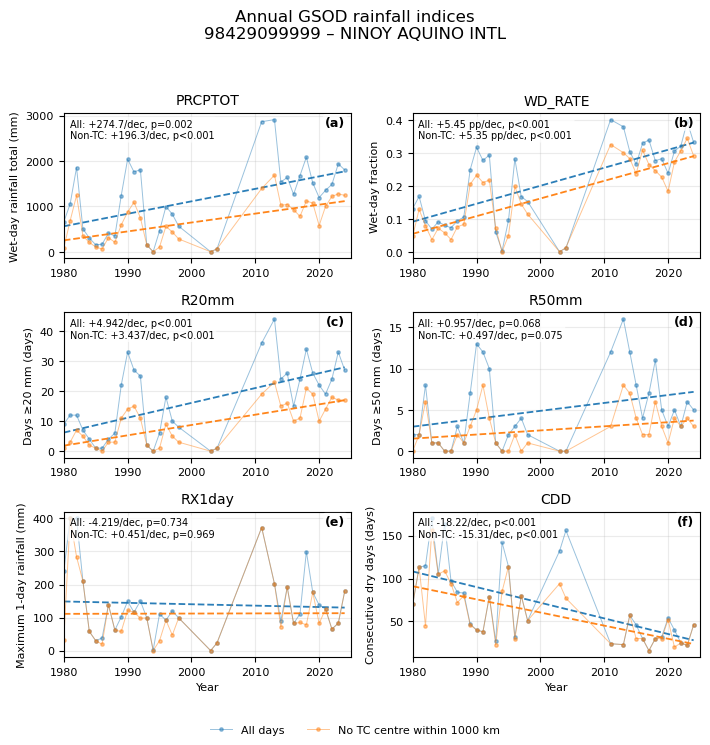

Saved: output/gsod_sanity_check/figures/composites/gsod_98429099999_annual_composite.png


In [49]:
station_id = "98429099999"

make_gsod_composite_timeseries_figure(
    data=gsod_all_period_indices,
    trend_summary=gsod_trend_summary,
    station_id=station_id,
    indices=GSOD_COMPOSITE_INDICES,
    period_type="Annual",
    period="Annual",
    output_path=GSOD_COMPOSITE_FIGURE_DIR / f"gsod_{station_id}_annual_composite.png",
    figure_title=f"Annual GSOD rainfall indices\n{station_label_from_id(station_id)}",
    ncols=2,
    panel_width=3.6,
    panel_height=2.45,
    annotate_stats=True,
)

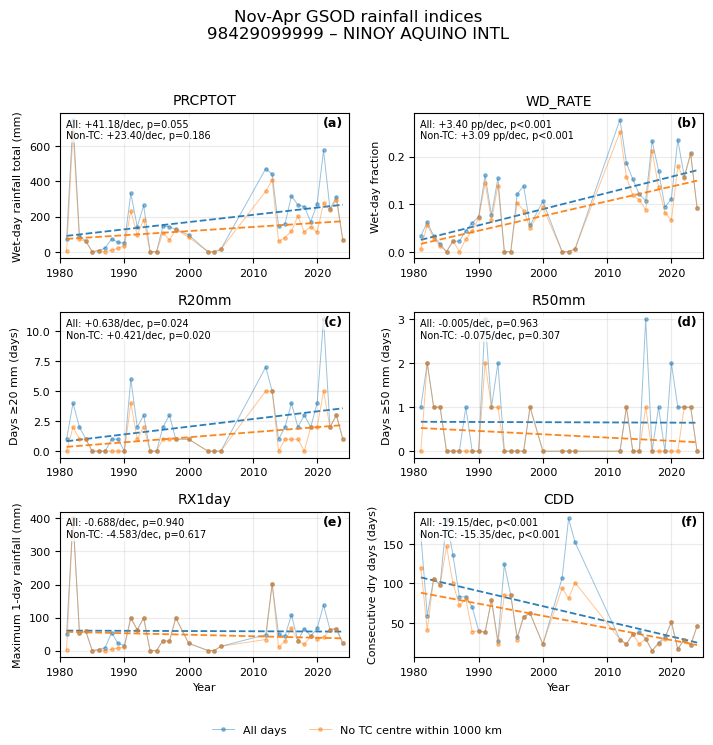

Saved: output/gsod_sanity_check/figures/composites/gsod_98429099999_nov_apr_composite.png


In [50]:
station_id = "98429099999"

make_gsod_composite_timeseries_figure(
    data=gsod_all_period_indices,
    trend_summary=gsod_trend_summary,
    station_id=station_id,
    indices=GSOD_COMPOSITE_INDICES,
    period_type="Seasonal",
    period=DRY_SEASON_LABEL,
    output_path=GSOD_COMPOSITE_FIGURE_DIR / f"gsod_{station_id}_nov_apr_composite.png",
    figure_title=f"{DRY_SEASON_LABEL} GSOD rainfall indices\n{station_label_from_id(station_id)}",
    ncols=2,
    panel_width=3.6,
    panel_height=2.45,
    annotate_stats=True,
)

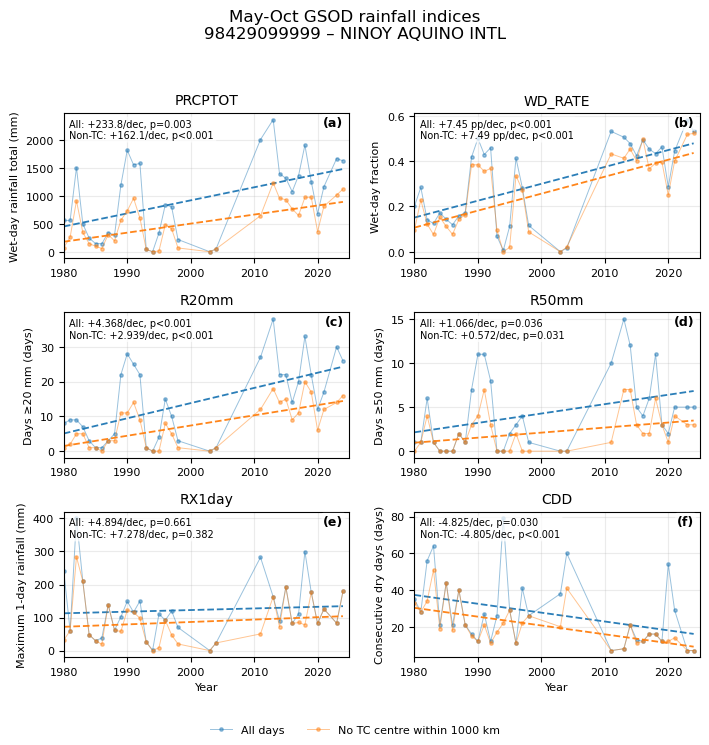

Saved: output/gsod_sanity_check/figures/composites/gsod_98429099999_may_oct_composite.png


In [51]:
station_id = "98429099999"

make_gsod_composite_timeseries_figure(
    data=gsod_all_period_indices,
    trend_summary=gsod_trend_summary,
    station_id=station_id,
    indices=GSOD_COMPOSITE_INDICES,
    period_type="Seasonal",
    period=WET_SEASON_LABEL,
    output_path=GSOD_COMPOSITE_FIGURE_DIR / f"gsod_{station_id}_may_oct_composite.png",
    figure_title=f"{WET_SEASON_LABEL} GSOD rainfall indices\n{station_label_from_id(station_id)}",
    ncols=2,
    panel_width=3.6,
    panel_height=2.45,
    annotate_stats=True,
)